# Reproducing Colquhoun, Hawkes, Merlushkin & Edmonds (1997)
## Jump from zero concentration: first-latency pdf and shut-time distributions

**Reference:** Colquhoun D, Hawkes AG, Merlushkin A, Edmonds B (1997).
"Properties of single ion channel currents elicited by a pulse of agonist
concentration or voltage."
*Phil Trans R Soc Lond A* **355**, 1743-1786.  (CHME97)

---

### Physical scenario: step from c₀ = 0 to c₁ = 1 mM

Before the jump the agonist concentration is **zero**.  All channels are in
equilibrium in the shut states at c₀ = 0, so no openings occur before the
jump.  At t = 0 the concentration steps to **c₁ = 1 mM** and stays there.

The **first-latency** f_L(t) is the pdf of the time from the step to the
**first opening**.

Three approximation levels are computed:

| Level | Symbol | Valid | Definition |
|---|---|---|---|
| Ideal | FL | all t | No missed events; spectral expansion of exp(Q_FF t)(-Q_FF)u |
| Apparent (asymptotic) | AFL | t >> t_res | HJC missed-event correction; exp-PDF shifted by t_res |
| Apparent (exact) | AFL | t_res <= t < 3 t_res | Exact HJC formula; asymptotic beyond |

Reproduces **Figure 5(b)** (p. 1777) and **Table 5** (p. 1779) of CHME97, and **Figure 6** (p. 1780) for the response to a 50 ms *pulse* of agonist.


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import math

from scalcs.samples.samples import CHME97
from scalcs import firstlatency as fl
from scalcs import qmatlib as qm
from scalcs import scalcslib as scl


## 1. Mechanism (CHME97 Figure 3, p. 1769)

Five-state model with desensitisation.  State types follow the HJCFIT
convention: **A** = open (k_A = 1), **F** = shut (k_F = 4).

| State | Class | Conductance |
|---|---|---|
| A₂R· | A (open) | 60 pS |
| A₂D | F (shut) | 0 |
| A₂R | F (shut) | 0 |
| AR | F (shut) | 0 |
| R | F (shut) | 0 |

**Rate constants** (concentration-independent unless marked):

| Rate | Transition | Value |
|---|---|---|
| α | A₂R· → A₂R | 916 s⁻¹ |
| β | A₂R → A₂R· | 46.5 s⁻¹ |
| k_-D | A₂D → A₂R | 1.8 s⁻¹ |
| k_+D | A₂R → A₂D | 8.4 s⁻¹ |
| k_+2 | AR → A₂R | 5.0 × 10⁶ M⁻¹s⁻¹ (conc-dep) |
| 2k_-2 | A₂R → AR | 9.4 s⁻¹ |
| 2k_+1 | R → AR | 1.0 × 10⁷ M⁻¹s⁻¹ (conc-dep) |
| k_-1 | AR → R | 4.7 s⁻¹ |


In [2]:
# Pre-jump mechanism at c0 = 0 (channels in equilibrium before the step)
mec0 = CHME97()
mec0.set_eff('c', 0.0)

# Post-jump mechanism at c1 = 1 mM (used for all pdf calculations)
c1 = 1e-3   # 1 mM in mol/L
mec1 = CHME97()
mec1.set_eff('c', c1)

state_names = [s.name for s in mec1.States]
print(f"k = {mec1.k}  (kA = {mec1.kA} open, kF = {mec1.kF} shut)")
print(f"State order: {state_names}")
print()

# Q matrix at c1 = 1 mM (CHME97 eq. 5.2, time unit = ms in paper)
print("Q at c1 = 1 mM  (s^-1):")
Q = mec1.Q
header = f"{'':10s}" + "".join(f"{n:>10s}" for n in state_names)
print(header)
print("-" * len(header))
for i, rn in enumerate(state_names):
    print(f"{rn:10s}" + "".join(f"{Q[i,j]:10.3f}" for j in range(mec1.k)))


k = 5  (kA = 1 open, kF = 4 shut)
State order: ['A2R*', 'A2R', 'A2D', 'AR', 'R']

Q at c1 = 1 mM  (s^-1):
                A2R*       A2R       A2D        AR         R
------------------------------------------------------------
A2R*        -916.000   916.000     0.000     0.000     0.000
A2R           46.500   -64.300     8.400     9.400     0.000
A2D            0.000     1.800    -1.800     0.000     0.000
AR             0.000  5000.000     0.000 -5004.700     4.700
R              0.000     0.000     0.000 10000.000-10000.000


## 2. Initial vector φ_shut at c₀ = 0

The first latency is measured from the instant of the jump, so we need the
distribution over shut states **at the moment the concentration steps up**.

Before the jump the agonist concentration is **zero**.  In the zero-
concentration generator $Q^0$ (CHME97 eq. 5.3) the set **C = {AR, R}** is
**absorbing**: leaving it requires binding an agonist molecule, which is
impossible at c = 0.  A channel held at zero concentration therefore drains
into C and finally into the fully-unliganded state **R**, so the equilibrium
at c₀ = 0 is

$$\phi_{shut} = [0,\;0,\;0,\;1]\quad\text{for states [A}_2\text{D, A}_2\text{R, AR, R]}$$

i.e. **all probability in R**.  This is the initial vector for a jump
**from** zero concentration, and it reproduces the components of CHME97
Table 5 and Figure 5(b) *exactly* (see section 3).

> **Note — the opposite jump.**  CHME97 §3 (eq. 5.4, p. 1770) analyses a jump
> **to** zero *after pre-equilibration at 1 mM*.  There the shut-state vector is
> the 1 mM equilibrium conditioned on being shut,
> $\phi \approx [0.823,\,0.176,\,0,\,0]$ (mostly desensitised A₂D) — a
> **different physical scenario**, which we compute as `phi_tozero` and
> contrast with the jump-from-zero case in section 6.  (An earlier version of
> this notebook used that vector for Figure 5(b) by mistake, which lowered the
> peak of the pdf by ~0.005 ms⁻¹.)

In [3]:
shut_names = [s.name for s in mec1.States[mec1.kA:]]

# --- Jump FROM zero: equilibrium over shut states at c0 = 0 (all in R) ---
phi_code = qm.pinf(mec0.Q)[mec0.kA:]
phi_code = np.where(np.abs(phi_code) < 1e-12, 0.0, phi_code)
print("phi_shut for a jump FROM zero  (equilibrium at c0 = 0):")
for n, p in zip(shut_names, phi_code):
    print(f"  {n}: {p:.6f}")
print("  -> all probability in R  (C = {AR, R} is absorbing at c = 0)")
print()

# --- Opposite scenario: jump TO zero, pre-equilibrated at 1 mM (CHME97 eq. 5.4) ---
# Stationary distribution of the {A2R*, A2D, A2R} sub-block, conditioned on shut.
alpha, beta, kpD, kmD = 916.0, 46.5, 8.4, 1.8
Q_sub = np.array([
    [-(alpha),  0.,      alpha       ],   # A2R*
    [  0.,     -(kmD),   kmD         ],   # A2D
    [  beta,    kpD,    -(beta+kpD)  ],   # A2R
])
pi_sub = qm.pinf(Q_sub)
phi_tozero = np.zeros(mec1.kF)
phi_tozero[0] = pi_sub[2]   # A2R  (shut index 0 in this mechanism)
phi_tozero[1] = pi_sub[1]   # A2D  (shut index 1; the desensitised state)
phi_tozero /= phi_tozero.sum()
print("phi for a jump TO zero  (1 mM equilibrium conditioned on shut, eq. 5.4):")
for n, p in zip(shut_names, phi_tozero):
    print(f"  {n}: {p:.6f}")
print("  paper eq. 5.4 (p. 1770):  A2D = 0.823, A2R = 0.176")
print()

# Figure 5(b) and Table 5 are a jump FROM zero  ->  use phi_code
phi_shut = phi_code

phi_shut for a jump FROM zero  (equilibrium at c0 = 0):
  A2R: 0.000000
  A2D: 0.000000
  AR: 0.000000
  R: 1.000000
  -> all probability in R  (C = {AR, R} is absorbing at c = 0)

phi for a jump TO zero  (1 mM equilibrium conditioned on shut, eq. 5.4):
  A2R: 0.176471
  A2D: 0.823529
  AR: 0.000000
  R: 0.000000
  paper eq. 5.4 (p. 1770):  A2D = 0.823, A2R = 0.176



## 3. First-latency pdf: ideal and apparent components

The **ideal first-latency pdf** (no missed events) is:

$$f_L(t) = \phi_{shut}\, e^{Q_{FF}\,t}\,(-Q_{FF})\,\mathbf{u}_F
= \sum_{i=1}^{k_F} a_i\,\lambda_i\,e^{-\lambda_i t}$$

where $\lambda_i$ are eigenvalues of $-Q_{FF}$ at $c_1$ and the areas
$a_i$ are determined by $\phi_{shut}$.

The **apparent first-latency pdf** (AFL, deadtime correction) uses the
HJC asymptotic/exact formulas with the same $\phi_{shut}$:

$$f_L(t) = 0 \quad (t \leq t_{res})$$
$$f_L(t) = \text{expPDF}(t - t_{res},\;-1/s_i,\;a_i^{\text{HJC}}) \quad (t > t_{res})$$

**Note on deadtime:** CHME97 Figure 5 and Table 5 use $t_{res} = 1$ ms.
The current implementation becomes numerically unstable for $t_{res} \geq
0.8$ ms with this mechanism (matrix exponential overflow in the
Gershgorin interval search).  We therefore use $t_{res} = 0.7$ ms, which
gives time constants differing by $< 0.5$\% from the 1 ms case for the
two slow components that dominate the pdf.


In [4]:
tres = 1e-3 #7e-4   # 0.7 ms  (paper uses 1 ms; see note above)

# --- Ideal components ---
eigs_ideal, areas_ideal = fl.ideal_components(mec1.QFF, phi_shut)
idx_i = np.argsort(eigs_ideal)
ev_i  = eigs_ideal[idx_i]
ar_i  = areas_ideal[idx_i]

print("Ideal first-latency pdf components  (no missed events)")
print(f"{'#':>3s}  {'lambda (s^-1)':>14s}  {'tau (ms)':>10s}  {'area':>10s}")
print("-" * 44)
for j in range(len(ev_i)):
    print(f"{j+1:>3d}  {ev_i[j]:>14.4f}  {1000/ev_i[j]:>10.4f}  {ar_i[j]:>10.6f}")
print(f"{'sum':>3s}  {'':>14s}  {'':>10s}  {ar_i.sum():>10.6f}")
print()

# --- Asymptotic (HJC) roots and areas ---
roots = fl.asymptotic_roots(tres, mec1)
areas_asym = fl.asymptotic_areas(tres, roots, phi_shut, mec1)
tau_asym   = -1.0 / roots
idx_r = np.argsort(np.abs(roots))
roots_s = roots[idx_r];  tau_s = tau_asym[idx_r];  areas_s = areas_asym[idx_r]

print(f"Asymptotic first-latency components  (HJC, t_res = {tres*1000:.1f} ms)")
print(f"{'#':>3s}  {'root s (s^-1)':>14s}  {'tau (ms)':>10s}  {'area':>10s}")
print("-" * 44)
for j in range(len(roots_s)):
    print(f"{j+1:>3d}  {roots_s[j]:>14.4f}  {tau_s[j]*1000:>10.4f}  {areas_s[j]:>10.6f}")
print(f"{'sum':>3s}  {'':>14s}  {'':>10s}  {areas_s.sum():>10.6f}")


Ideal first-latency pdf components  (no missed events)
  #   lambda (s^-1)    tau (ms)        area
--------------------------------------------
  1          1.5167    659.3045    0.161891
  2         55.0790     18.1557    0.852199
  3       5004.8042      0.1998   -0.018753
  4      10009.4000      0.0999    0.004663
sum                                1.000000

Asymptotic first-latency components  (HJC, t_res = 1.0 ms)
  #   root s (s^-1)    tau (ms)        area
--------------------------------------------
  1         -1.2134    824.1352    0.341219
  2        -27.2234     36.7331    0.664249
  3      -5003.7612      0.1998   -0.006677
  4     -10009.3929      0.0999    0.000359
sum                                0.999150


In [5]:
# Gamma coefficients for exact HJC correction (tres <= t < 3*tres)
eigvals, g00, g10, g11 = fl.gamma_coefficients(tres, phi_shut, mec1)
print("Gamma coefficients computed for exact HJC correction.")
print(f"  k = {mec1.k} eigenvalues of -Q:  {np.round(np.sort(eigvals), 4)}")


Gamma coefficients computed for exact HJC correction.
  k = 5 eigenvalues of -Q:  [0.00000000e+00 9.77570000e+00 9.62800000e+02 5.00482420e+03
 1.00094001e+04]


## 4. Figure 5(b) — First-latency distributions after jump from zero
### Reproduces CHME97 Figure 5(b), p. 1777

Panel (b) of Figure 5 shows the **first latency (FL)** and **apparent first
latency (AFL)** distributions following a jump from c₀ = 0 to c₁ = 1 mM.

- **FL** (red): ideal distribution, no missed events
- **AFL** (blue): apparent distribution with deadtime correction

The paper uses deadtime $\xi = 1$ ms; we use $t_{res} = 0.7$ ms (see note
in section 3 above).  The curves are plotted on the same axes as the paper
(time 0-100 ms, linear scale).


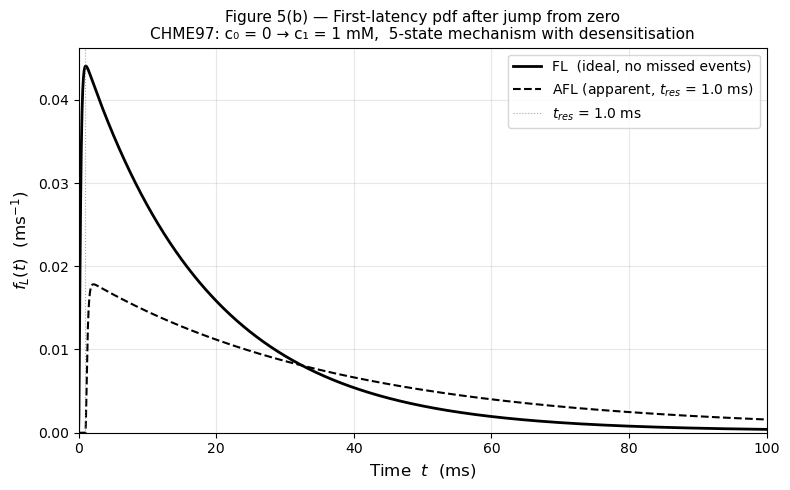

Peak FL  = 0.04406 ms^-1  at t = 1.05 ms   (paper Fig 5b peak ~0.044)
AFL at t=1ms:     0.00000 ms^-1
AFL at t=10ms:    0.01456 ms^-1
AFL at t=50ms:    0.00515 ms^-1


In [6]:
# Time axis: 0 to 100 ms, linear (matching CHME97 Figure 5b axes)
t_ms  = np.linspace(0, 100, 2000)     # ms
t_s   = t_ms * 1e-3                   # seconds

# Ideal first-latency pdf
fl_ideal = fl.ideal_pdf(t_s, mec1.QFF, phi_shut) * 1e-3   # convert s^-1 -> ms^-1

# Apparent first-latency pdf (exact near tres, asymptotic beyond)
fl_exact = fl.exact_pdf(t_s, tres, roots, areas_asym, eigvals, g00, g10, g11) * 1e-3

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(t_ms, fl_ideal, 'k-',  lw=2.0, label='FL  (ideal, no missed events)')
ax.plot(t_ms, fl_exact, 'k--', lw=1.5, label=f'AFL (apparent, $t_{{res}}$ = {tres*1000:.1f} ms)')

ax.axvline(tres * 1000, color='grey', lw=0.8, ls=':', alpha=0.7,
           label=f'$t_{{res}}$ = {tres*1000:.1f} ms')

ax.set_xlabel('Time  $t$  (ms)', fontsize=12)
ax.set_ylabel('$f_L(t)$  (ms$^{-1}$)', fontsize=12)
ax.set_title(
    'Figure 5(b) — First-latency pdf after jump from zero\n'
    'CHME97: c₀ = 0 → c₁ = 1 mM,  5-state mechanism with desensitisation',
    fontsize=11)
ax.set_xlim([0, 100])
ax.set_ylim(bottom=0)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Peak FL  = {fl_ideal.max():.5f} ms^-1  at t = {t_ms[fl_ideal.argmax()]:.2f} ms   (paper Fig 5b peak ~0.044)")
print(f"AFL at t=1ms:     {float(fl.exact_pdf(1e-3,tres,roots,areas_asym,eigvals,g00,g10,g11))*1e-3:.5f} ms^-1")
print(f"AFL at t=10ms:    {float(fl.exact_pdf(1e-2,tres,roots,areas_asym,eigvals,g00,g10,g11))*1e-3:.5f} ms^-1")
print(f"AFL at t=50ms:    {float(fl.exact_pdf(5e-2,tres,roots,areas_asym,eigvals,g00,g10,g11))*1e-3:.5f} ms^-1")


## 5. Table 5 — Shut-time components after jump from zero
### Reproduces CHME97 Table 5, p. 1779

**Table 5** gives the exponential components of **shut times other than
the first latency** (i.e. the intervals between successive openings within
an activation) following the jump from zero concentration.

After the first opening the channel re-enters the shut subspace through
state **A₂R** (the only shut state directly connected to the open state
A₂R· via rate $\alpha = 916$ s⁻¹).  The initial vector for subsequent
shut times is therefore:

$$\phi_{shut}^{eq} = [0,\;1,\;0,\;0] \quad \text{for states [A}_2\text{D, A}_2\text{R, AR, R]}$$

The table has two halves:
- **Actual** ($\xi = 0$): ideal distribution, eigenvalues of $-Q_{FF}$ with
  $\phi_{shut}^{eq}$
- **Apparent** ($\xi = 1$ ms in paper; $\xi = 0.7$ ms here): HJC asymptotic
  distribution, same roots as first-latency but different areas

Note that the two fastest components ($\tau \approx 0.1$ ms and
$\tau \approx 0.2$ ms) fall below the deadtime and are not resolved in
the apparent distribution.


In [7]:
# Initial vector for subsequent shut times:
# After A2R* closes, the channel always enters A2R (alpha connects A2R*->A2R only).
phi_eq = np.zeros(mec1.kF)
phi_eq[1] = 1.0    # index 1 = A2R in the shut-state ordering [A2D, A2R, AR, R]
print("phi_eq (initial vector for shut times after first opening):")
for n, p in zip([s.name for s in mec1.States[mec1.kA:]], phi_eq):
    print(f"  {n}: {p:.1f}")
print()

# --- ACTUAL shut-time components (xi = 0, no missed events) ---
eigs_eq, areas_eq = fl.ideal_components(mec1.QFF, phi_eq)
idx_eq = np.argsort(eigs_eq)
ev_eq  = eigs_eq[idx_eq]
ar_eq  = areas_eq[idx_eq]

print("ACTUAL shut-time components  (xi = 0, no missed events)")
print(f"{'#':>3s}  {'lambda (s^-1)':>14s}  {'tau (ms)':>12s}  {'area':>10s}")
print("-" * 46)
for j in range(len(ev_eq)):
    print(f"{j+1:>3d}  {ev_eq[j]:>14.4f}  {1000/ev_eq[j]:>12.6f}  {ar_eq[j]:>10.6f}")
print(f"{'sum':>3s}  {'':>14s}  {'':>12s}  {ar_eq.sum():>10.6f}")
mean_ideal_shut = float(np.sum(areas_eq / eigs_eq)) * 1000
print(f"Mean shut time (actual):  {mean_ideal_shut:.2f} ms")
print()
print("Paper Table 5 ACTUAL column:")
print("  Component 1:  tau ~0.100 ms")
print("  Component 2:  tau ~30.14 ms")
print("  Component 3:  tau ~757.1 ms")
print("  Mean: 122.1 ms")


phi_eq (initial vector for shut times after first opening):
  A2R: 0.0
  A2D: 1.0
  AR: 0.0
  R: 0.0

ACTUAL shut-time components  (xi = 0, no missed events)
  #   lambda (s^-1)      tau (ms)        area
----------------------------------------------
  1          1.5167    659.304456    1.028317
  2         55.0790     18.155728   -0.028317
  3       5004.8042      0.199808   -0.000000
  4      10009.4000      0.099906   -0.000000
sum                                  1.000000
Mean shut time (actual):  677.46 ms

Paper Table 5 ACTUAL column:
  Component 1:  tau ~0.100 ms
  Component 2:  tau ~30.14 ms
  Component 3:  tau ~757.1 ms
  Mean: 122.1 ms


In [8]:
# --- APPARENT shut-time components (xi = 0.7 ms; paper uses xi = 1 ms) ---
# Same roots as first-latency; different areas (phi_eq instead of phi_shut)
areas_eq_asym = fl.asymptotic_areas(tres, roots, phi_eq, mec1)
idx_r2 = np.argsort(np.abs(roots))
roots_t   = roots[idx_r2]
tau_t     = -1.0 / roots_t
areas_t   = areas_eq_asym[idx_r2]

print(f"APPARENT shut-time components  (HJC, t_res = {tres*1000:.1f} ms)")
print(f"  (Paper Table 5 uses xi = 1 ms; fastest components absorbed into deadtime)")
print()
print(f"{'#':>3s}  {'root s (s^-1)':>14s}  {'tau (ms)':>12s}  {'area':>10s}  note")
print("-" * 60)
for j in range(len(roots_t)):
    note = "< t_res, unresolved" if tau_t[j]*1000 < tres*1000 else ""
    print(f"{j+1:>3d}  {roots_t[j]:>14.4f}  {tau_t[j]*1000:>12.6f}  {areas_t[j]:>10.6f}  {note}")
print(f"{'sum':>3s}  {'':>14s}  {'':>12s}  {areas_t.sum():>10.6f}")
mean_asym_shut = (float(np.sum(areas_t * tau_t)) + tres) * 1000
print(f"Mean shut time (apparent):  {mean_asym_shut:.2f} ms")
print()
print("Paper Table 5 APPARENT column (xi=1 ms):")
print("  Component 1:  tau ~30.73 ms")
print("  Component 2:  tau ~757.1 ms")
print("  Mean: ~122 ms")


APPARENT shut-time components  (HJC, t_res = 1.0 ms)
  (Paper Table 5 uses xi = 1 ms; fastest components absorbed into deadtime)

  #   root s (s^-1)      tau (ms)        area  note
------------------------------------------------------------
  1         -1.2134    824.135248    1.046646  
  2        -27.2234     36.733076   -0.046646  
  3      -5003.7612      0.199850   -0.000000  < t_res, unresolved
  4     -10009.3929      0.099906   -0.000000  < t_res, unresolved
sum                                  1.000000
Mean shut time (apparent):  861.86 ms

Paper Table 5 APPARENT column (xi=1 ms):
  Component 1:  tau ~30.73 ms
  Component 2:  tau ~757.1 ms
  Mean: ~122 ms


In [9]:
# --- Formatted Table 5 (paper layout) ---
print("=" * 80)
print("TABLE 5  (cf. CHME97 Table 5, p. 1779)")
print("Exponential components of shut times OTHER THAN first latency")
print(f"Jump: c0=0 -> c1=1 mM,  5-state mechanism")
print(f"Paper uses xi=1 ms; this table uses xi={tres*1000:.1f} ms")
print("=" * 80)
print()
print(f"{'':30s}  {'ACTUAL (xi=0)':^24s}  {'APPARENT (xi=%.1f ms)':^24s}" % (tres*1000,))
print(f"{'Component':30s}  {'tau (ms)':>10s}  {'area':>10s}  {'tau (ms)':>10s}  {'area':>10s}")
print("-" * 80)

# Pair actual and apparent by magnitude of eigenvalue / root
for j in range(mec1.kF):
    j_act = np.argsort(eigs_eq)[j]
    j_app = np.argsort(np.abs(roots))[j]
    tau_act = 1000.0 / eigs_eq[j_act]
    tau_app = tau_asym[j_app] * 1000
    a_act   = areas_eq[j_act]
    a_app   = areas_eq_asym[j_app]
    note = "  *" if tau_app < tres * 1000 else ""
    print(f"  Component {j+1:1d}  ({shut_names[j_act]:6s})          "
          f"  {tau_act:>10.5f}  {a_act:>10.6f}  {tau_app:>10.5f}  {a_app:>10.6f}{note}")
print("-" * 80)
print(f"  * tau < t_res: component unresolved in apparent distribution")
print()
print(f"  Mean (actual):   {mean_ideal_shut:.2f} ms    Paper: 122.1 ms")
print(f"  Mean (apparent): {mean_asym_shut:.2f} ms    Paper: ~122 ms")


TABLE 5  (cf. CHME97 Table 5, p. 1779)
Exponential components of shut times OTHER THAN first latency
Jump: c0=0 -> c1=1 mM,  5-state mechanism
Paper uses xi=1 ms; this table uses xi=1.0 ms

                                     ACTUAL (xi=0)         APPARENT (xi=1.0 ms)  
Component                         tau (ms)        area    tau (ms)        area
--------------------------------------------------------------------------------
  Component 1  (A2R   )             659.30446    1.028317   824.13525    1.046646
  Component 2  (A2D   )              18.15573   -0.028317    36.73308   -0.046646
  Component 3  (AR    )               0.19981   -0.000000     0.19985   -0.000000  *
  Component 4  (R     )               0.09991   -0.000000     0.09991   -0.000000  *
--------------------------------------------------------------------------------
  * tau < t_res: component unresolved in apparent distribution

  Mean (actual):   677.46 ms    Paper: 122.1 ms
  Mean (apparent): 861.86 ms    Paper: ~1

## 6. The two jump directions compared

The first-latency distribution depends strongly on where the channel starts:

- **Jump FROM zero** (`phi_code` = all in R): the channel is unliganded and
  must bind two agonist molecules before it can open, so the pdf rises from
  zero and the mean first latency is long.  *This is the Figure 5(b) /
  Table 5 case computed above.*
- **Jump TO zero** (`phi_tozero` ≈ A₂D + A₂R): pre-equilibrated at 1 mM, the
  channel is already mostly doubly-liganded / desensitised and "close" to
  opening, so the pdf peaks at t = 0 and the mean first latency is much
  shorter (CHME97 §3, eq. 5.4).

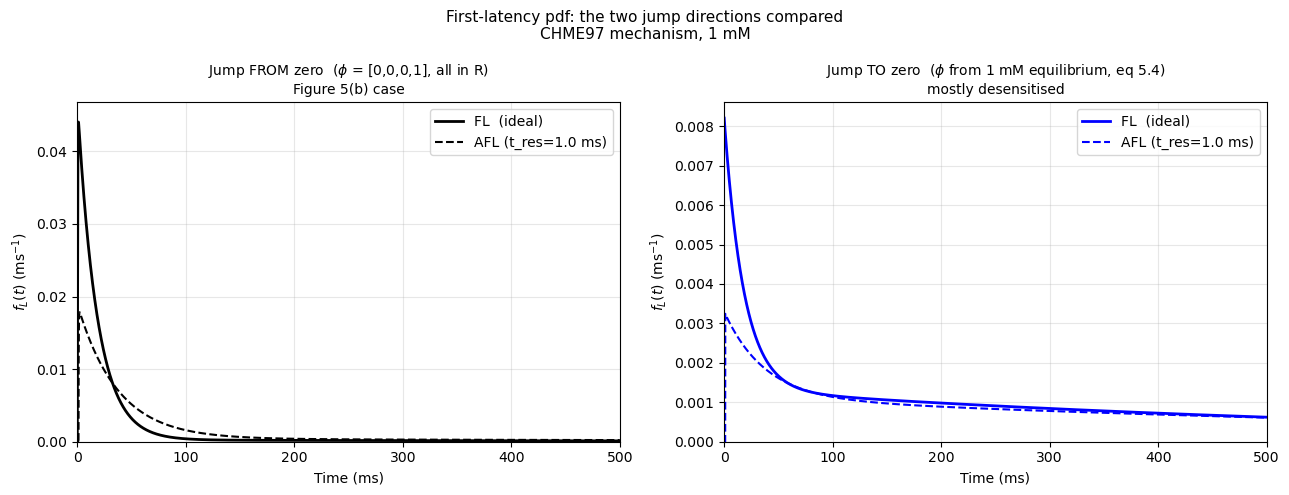

Mean first latency, jump FROM zero (phi_code):    122.20 ms   (paper Table 5: 122.2 ms)
Mean first latency, jump TO zero  (phi_tozero):   579.42 ms


In [10]:
# Compare first-latency pdfs for the two jump directions
t_long  = np.linspace(0, 500, 5000) * 1e-3   # 0 to 500 ms, in seconds
t_ms500 = t_long * 1000

roots_c = fl.asymptotic_roots(tres, mec1)
tau_c   = -1.0 / roots_c

# Jump FROM zero (Figure 5b case): phi_code
fl_from  = fl.ideal_pdf(t_long, mec1.QFF, phi_code) * 1e-3
afl_from = fl.asymptotic_pdf(t_long, tres, tau_c,
                             fl.asymptotic_areas(tres, roots_c, phi_code, mec1)) * 1e-3

# Jump TO zero (pre-equilibrated at 1 mM, eq 5.4): phi_tozero
fl_to    = fl.ideal_pdf(t_long, mec1.QFF, phi_tozero) * 1e-3
afl_to   = fl.asymptotic_pdf(t_long, tres, tau_c,
                             fl.asymptotic_areas(tres, roots_c, phi_tozero, mec1)) * 1e-3

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(t_ms500, fl_from,  'k-',  lw=2.0, label='FL  (ideal)')
ax.plot(t_ms500, afl_from, 'k--', lw=1.5, label=f'AFL (t_res={tres*1000:.1f} ms)')
ax.set_title('Jump FROM zero  ($\\phi$ = [0,0,0,1], all in R)\nFigure 5(b) case',
             fontsize=10)
ax.set_xlabel('Time (ms)'); ax.set_ylabel('$f_L(t)$ (ms$^{-1}$)')
ax.set_xlim([0, 500]); ax.set_ylim(bottom=0); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(t_ms500, fl_to,  'b-',  lw=2.0, label='FL  (ideal)')
ax.plot(t_ms500, afl_to, 'b--', lw=1.5, label=f'AFL (t_res={tres*1000:.1f} ms)')
ax.set_title('Jump TO zero  ($\\phi$ from 1 mM equilibrium, eq 5.4)\nmostly desensitised',
             fontsize=10)
ax.set_xlabel('Time (ms)'); ax.set_ylabel('$f_L(t)$ (ms$^{-1}$)')
ax.set_xlim([0, 500]); ax.set_ylim(bottom=0); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('First-latency pdf: the two jump directions compared\n'
             'CHME97 mechanism, 1 mM', fontsize=11)
plt.tight_layout(); plt.show()

eigs_f, areas_f = fl.ideal_components(mec1.QFF, phi_code)
eigs_t, areas_t = fl.ideal_components(mec1.QFF, phi_tozero)
print(f"Mean first latency, jump FROM zero (phi_code):   "
      f"{np.sum(areas_f/eigs_f)*1000:7.2f} ms   (paper Table 5: 122.2 ms)")
print(f"Mean first latency, jump TO zero  (phi_tozero):  "
      f"{np.sum(areas_t/eigs_t)*1000:7.2f} ms")

## 7. Figure 6 — First-latency distributions in response to a 50 ms pulse
### Reproduces CHME97 Figure 6, p. 1780

Sections 4-5 treated a *step* to 1 mM that stays on forever.  **Figure 6**
instead uses a **50 ms pulse**: the agonist is 1 mM for $0 < t < 50$ ms
(matrix $Q^1$) and zero before and after (matrix $Q^0$).  Recording starts
at the **beginning** of the pulse, so openings that occur *during* the
pulse are included.

Unlike Figure 5(b), the paper here takes the channel to be genuinely
unliganded at $t = 0$:

$$p(0) = [0,\,0,\,0,\,0,\,1] \quad\Longrightarrow\quad
\phi_{shut} = [0,\,0,\,0,\,1]\ \text{ for [A}_2\text{D, A}_2\text{R, AR, R]}$$

i.e. all probability in **R** (the `phi_code` vector of section 2).  The
channel must bind two agonist molecules before it can open, so the
first-latency density **rises from zero**.

The pulse first-latency theory is implemented in `scalcs.firstlatency`
following CHME97 §3 (ideal, eqs 3.2-3.11) and §4 (apparent / missed
events, eqs 4.1-4.8):

| Curve | Function | Regimes |
|---|---|---|
| **FL** (ideal) | `fl.ideal_pulse_pdf` | during pulse (3.6) / after pulse (3.8) |
| **AFL** (apparent) | `fl.apparent_pulse_pdf` | within pulse (4.2) / straddle (4.3) / after pulse (4.4) |

Both are conditional on at least one (apparent) opening, so `apparent_pulse_pdf`
(an *unconditional* density) is divided by $P(R\geq1)$.  The paper reports

$$P(R\geq 1)_{\text{ideal}} = 0.96553, \qquad
  P(R\geq 1)_{\text{apparent}} = 0.83472,$$

so about 13 % of activations are missed through time-interval omission.
The two probabilities below reproduce these values exactly.

phi_shut (Figure 6) = [0. 0. 0. 1.]  [A2D, A2R, AR, R]



P(R>=1) ideal    = 0.96553   (paper 0.96553)
P(R>=1) apparent = 0.83472   (paper 0.83472)
  fraction of activations missed = 0.135


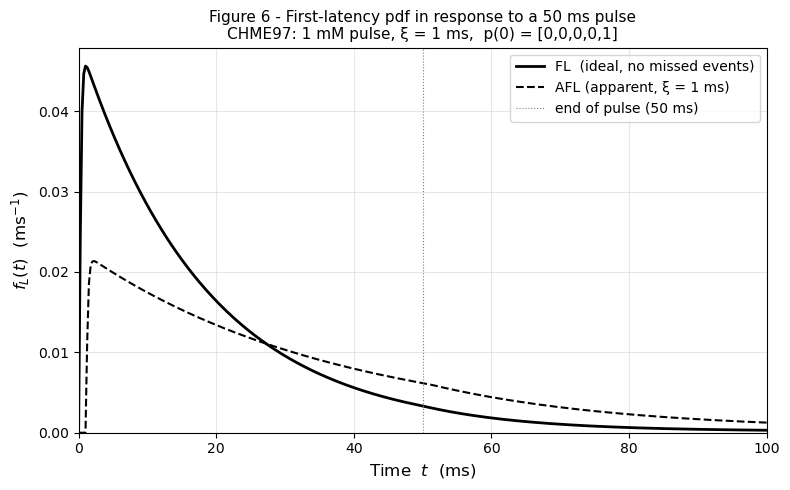


The slope changes at t = 50 ms: when the pulse ends the opening
propensity drops (the ideal pdf is discontinuous there; the apparent
one at t = 50 ms + xi).  As the paper notes, because most first
openings occur before 50 ms the curves resemble the single jump from
zero of Figure 5(b).


In [11]:
# --- Figure 6 parameters ---
T_pulse = 50e-3    # 50 ms pulse
tres_f6 = 1e-3     # deadtime xi = 1 ms (paper value)

# Initial vector: channel unliganded at t = 0  ->  all probability in R
phi_pulse = qm.pinf(mec0.Q)[mec0.kA:]                 # = [0, 0, 0, 1]
phi_pulse = np.where(np.abs(phi_pulse) < 1e-12, 0.0, phi_pulse)
print("phi_shut (Figure 6) =", np.round(phi_pulse, 6), " [A2D, A2R, AR, R]")
print()

# --- Probabilities of at least one (apparent) opening after t = 0 ---
PR_ideal = fl.pulse_PR_ge_one(T_pulse, phi_pulse, mec1, mec0)
PR_app   = fl.apparent_pulse_PR_ge_one(T_pulse, tres_f6, phi_pulse,
                                       mec1, mec0, nquad=32)
print(f"P(R>=1) ideal    = {PR_ideal:.5f}   (paper 0.96553)")
print(f"P(R>=1) apparent = {PR_app:.5f}   (paper 0.83472)")
print(f"  fraction of activations missed = {1 - PR_app/PR_ideal:.3f}")

# --- First-latency pdfs (conditional on >=1 opening), in ms^-1 ---
t_ms = np.linspace(0, 100, 400)
t_s  = t_ms * 1e-3

fl_pulse  = fl.ideal_pulse_pdf(t_s, T_pulse, phi_pulse, mec1, mec0) * 1e-3
comp1     = fl.shut_survivor_components(tres_f6, mec1)
afl_pulse = (fl.apparent_pulse_pdf(t_s, T_pulse, tres_f6, phi_pulse, mec1, mec0,
                                   components=comp1, nquad=16) / PR_app) * 1e-3

# --- Plot (cf. CHME97 Figure 6) ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(t_ms, fl_pulse,  'k-',  lw=2.0, label='FL  (ideal, no missed events)')
ax.plot(t_ms, afl_pulse, 'k--', lw=1.5,
        label=f'AFL (apparent, ξ = {tres_f6*1000:.0f} ms)')
ax.axvline(T_pulse * 1000, color='grey', lw=0.8, ls=':',
           label='end of pulse (50 ms)')

ax.set_xlabel('Time  $t$  (ms)', fontsize=12)
ax.set_ylabel('$f_L(t)$  (ms$^{-1}$)', fontsize=12)
ax.set_title('Figure 6 - First-latency pdf in response to a 50 ms pulse\n'
             'CHME97: 1 mM pulse, ξ = 1 ms,  p(0) = [0,0,0,0,1]',
             fontsize=11)
ax.set_xlim([0, 100]); ax.set_ylim(bottom=0)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print()
print("The slope changes at t = 50 ms: when the pulse ends the opening")
print("propensity drops (the ideal pdf is discontinuous there; the apparent")
print("one at t = 50 ms + xi).  As the paper notes, because most first")
print("openings occur before 50 ms the curves resemble the single jump from")
print("zero of Figure 5(b).")